In [27]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [16]:
from scipy.stats import bernoulli #Follows PMF which works for discreate random variables. 
#Bernouli distribution has exactly two possible outcomes. eg True or False, Head or Tails, Yes or No, Success or Failure 

# Define the probability of success
p_success = 0.7

# Create a Bernoulli distribution object
bernoulli_dist = bernoulli(p_success)
print("bernoulli_dist: ", bernoulli_dist)

# Calculate the PMF for k=1 (success) and k=0 (failure)
prob_success_scipy = bernoulli_dist.pmf(1)
prob_failure_scipy = bernoulli_dist.pmf(0)
print("prob_success_scipy: ", prob_success_scipy)
print("prob_failure_scipy: ", prob_failure_scipy)

variance_manual = p_success * (prob_failure_scipy) # (1-p_success)

# Generate a random sample from the distribution
random_sample = bernoulli_dist.rvs(size=10)

print(f"The probability of success (k=1) using scipy is: {prob_success_scipy}")
print(f"The probability of failure (k=0) using scipy is: {prob_failure_scipy}")
# Mean is equals to the value p(probability of success)
print(f"The mean of bernoulli distribution using scipy is: {bernoulli_dist.mean()}")
# Median is if q < p then 1, if q > p then 0 and if q = p then 0.5
print(f"The median of bernoulli distribution using scipy is: {bernoulli_dist.median()}")
# Mode - If p > q then p is mode else q will be the mode
print(f"The variance of bernouli distribution: {variance_manual}")

print(f"A random sample of 10 trials is: {random_sample}")

bernoulli_dist:  <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c40689dac60>
prob_success_scipy:  0.7
prob_failure_scipy:  0.30000000000000004
The probability of success (k=1) using scipy is: 0.7
The probability of failure (k=0) using scipy is: 0.30000000000000004
The mean of bernoulli distribution using scipy is: 0.7
The median of bernoulli distribution using scipy is: 1.0
The variance of bernouli distribution: 0.21000000000000002
A random sample of 10 trials is: [1 1 1 1 1 1 0 0 0 1]


__Binomial Distribution This also PMF distribution and follows discreate random variable. just like bernouli__

In [2]:
%pip install scipy --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.0 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 3.5 MB/s eta 0:00:00m eta 0:00:010:00:01m
Note: you may need to restart the kernel to use updated packages.


__The primary difference between Bernoulli and Binomial distributions is the number of trials they model. A Bernoulli distribution is for a single trial, while a Binomial distribution is for multiple, repeated trials__ 

__The binomial distribution models the number of successes in a fixed number of independent trials. It's defined by two main parameters: the number of trials (n) and the probability of success in each trial (p).__

dist:  <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ce4dea086b0>
The probability of exactly 3 successes is: 0.3125
A random sample of 5 outcomes: [1]
mean:  2.5 variance:  1.25 median:  2.0
probabilities:  [0.03125 0.15625 0.3125  0.3125  0.15625 0.03125]


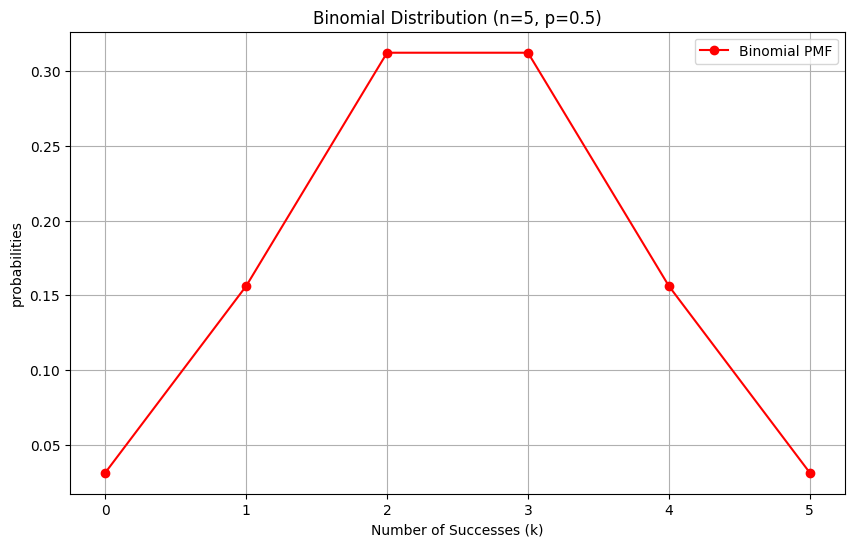

In [4]:
import numpy as np
from scipy.stats import binom 
import matplotlib.pyplot as plt

# Parameters for the binomial distribution - 60% chances of making 4s while batting in 10 bowls.
n_trials = 5  # Number of trials
p_success = 0.5  # Probability of success in each trial

# Create a binomial distribution object
dist = binom(n=n_trials, p=p_success)

print("dist: ", dist)
# Calculate the probability mass function (PMF) of hitting 7 4s successes while batting put of 10 bowls.
k_success = 3
prob = dist.pmf(k_success)
print(f"The probability of exactly {k_success} successes is: {prob:.4f}")

# Generate a random sample of 5 trials
random_sample = dist.rvs(size=1)
print(f"A random sample of 5 outcomes: {random_sample}")

mean = dist.mean()      # Expected number of successful shots
variance = dist.var()   # How much the results might vary
median = dist.median()  # The middle value of the outcomes
print("mean: ", mean, "variance: ", variance, "median: ", median)

# Below practice of binomial distribution to practice matplotlib library
# Get all possible values for k (number of successes)
k_values = np.arange(n_trials + 1)

# Calculate the probability for each k value
probabilities = dist.pmf(k_values)
print("probabilities: ", probabilities)
plt.figure(figsize=(10, 6))
random_sample = dist.rvs(size=1)
plt.plot(k_values, probabilities, "o-", color="red", label="Binomial PMF")
plt.xlabel("Number of Successes (k)")

plt.ylabel("probabilities")

plt.title(f"Binomial Distribution (n={n_trials}, p={p_success})")

plt.legend()

plt.grid(True)
plt.show()


__Using our example, comb(10, 7) calculates the number of different ways you can make exactly 7 shots and miss 3.__

In [24]:
from scipy.special import comb

# Parameters
n = 10  # Total number of items
k = 7   # Number of items to choose

# Calculate the binomial coefficient
b_coefficient = comb(n, k)

print(f"The binomial coefficient for choosing {k} from {n} is: {b_coefficient}")
print(f"You have {b_coefficient} ways to make exactly 7 shots and miss 3")

The binomial coefficient for choosing 7 from 10 is: 120.0
You have 120.0 ways to make exactly 7 shots and miss 3


__Poisson Distribution__

Definition:
A distribution that describes the probability of a given number of events happening in a fixed interval of time or space, when events occur with a known constant rate (λ) and independently of each other.

Use case:
Counts of rare events over time/space (e.g., number of customer arrivals per minute, number of emails per hour).
Parameters:
𝜆
λ: expected number of events in the interval (rate).

Example:
On average, 5 cars pass a checkpoint per minute. What’s the probability exactly 7 cars pass in the next minute?

In [46]:
from scipy.stats import poisson
average_rate = 5

poisson_dist = poisson(mu=average_rate)
print(poisson_dist)
specific_events=7
probability = poisson_dist.pmf(specific_events)
print("mean: ", poisson_dist.mean())
print("probability of exactly 7 cars pass per minute: ", probability)

mean:  5.0
probability of exactly 7 cars pass in the next minute:  0.17546736976785068


__Normal/Gaussian distribution. It is a type of continuous prbability distribution for a real valued variable__
__It follows continous random variable which PDF__
__Probability distribution that's symmetrical around its mean, showing that data points closer to the mean are more frequent than those far away. 📊 It's often called a bell curve because of its distinctive shape.__
__The two key parameters of a Normal distribution are the mean(μ) and standard deviation(σ)__
__Standard deviation(σ) which measures the spread or dispersion of the data. A small standard deviation means the data points are clustered closely around the mean, while a large one indicates they're more spread out.__
Diagram of normal distribution will always be bell - curve. most of the avg data will be close to the mean.

Sample of generated heights (cm): [174.96714153 168.61735699 176.47688538 185.23029856 167.65846625]
Sample of generated weights (kg): [74.79548806 71.47243578 65.41741259 60.47144256 69.8875632 ]
prob:  [0.0053991  0.00862773 0.01295176 0.01826491 0.02419707]
xmin: 134.04032718394737 xmax:  212.07431432190913


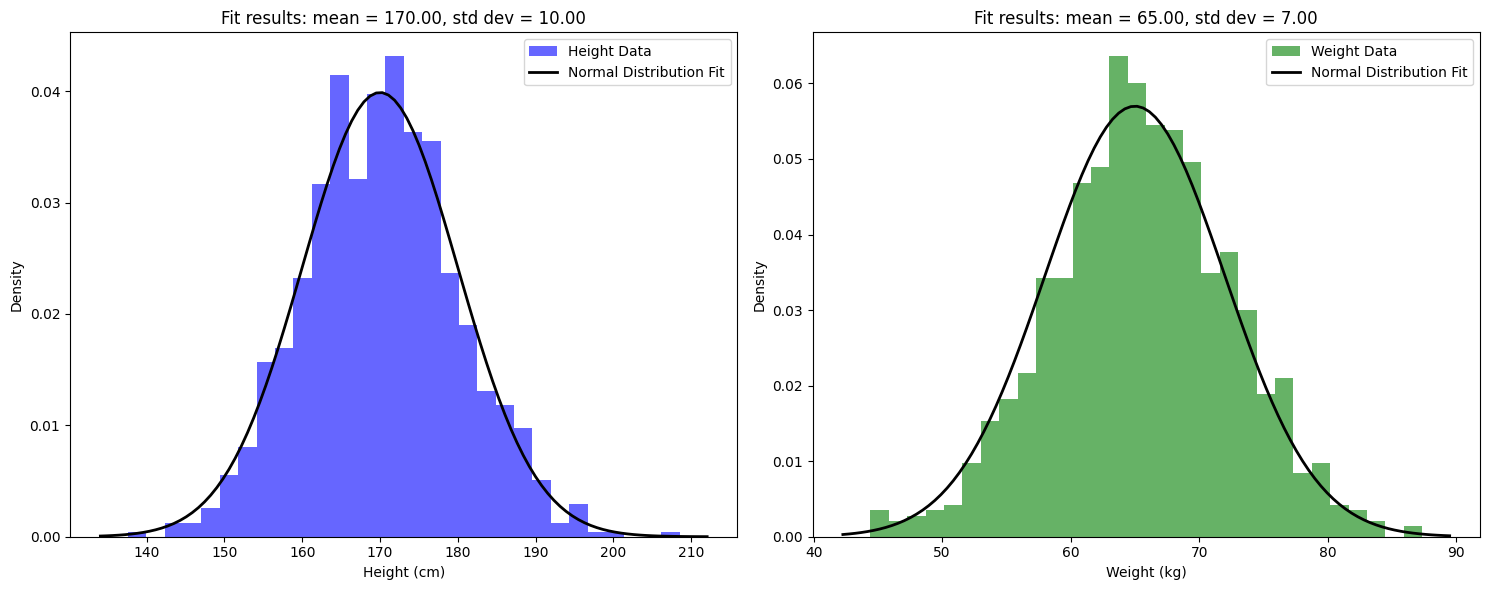

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# set a random seeds for reproducibility
np.random.seed(42)
mean_height = 170 # in cm
std_dev_height = 10
mean_weight = 65 # in kg
std_dev_weight = 7

num_students = 1000
# Generate a synthetic dataset for 1000 students
heights = np.random.normal(mean_height, std_dev_height, num_students)
weights = np.random.normal(mean_Weight, std_dev_weight, num_students)
# Print a few data points to see what we've generated
print("Sample of generated heights (cm):", heights[:5])
print("Sample of generated weights (kg):", weights[:5])
# checking the probability density of a student having height between 150 to 160 cm, where 170 cm is mean and standard deviation is 10
x_height = np.linspace(150, 160, 5)
prob = norm.pdf(x_height, 170, 10)
print("prob: ", prob)
# Create a figure with two subplots
# plt.subplots() is a Matplotlib function that returns a figure and one or more axes (subplots).
# fig is the overall container or "canvas" for the plot.
"""
(ax1, ax2) are the individual plots or axes within the figure. ax1 is the first subplot on the left, and ax2 is the second one on 
the right.
(1, 2) specifies the layout: 1 row and 2 columns.
figsize=(15, 6) sets the size of the entire figure in inches, with a width of 15 and a height of 6.
"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the distribution of heights
# The width of each bin is calculated by dividing the range by the number of bins
ax1.hist(heights, bins=30, density=True, alpha=0.6, color='b', label='Height Data')
# xmin, xmax = ax1.get_xlim() retrieves the minimum and maximum values of the x-axis for ax1. This is done to ensure that any 
#subsequent plots, like a Normal distribution curve, are drawn over the same range as the histogram.
# x_height = np.linspace(xmin, xmax, 100) generates 100 evenly spaced points between xmin and xmax. This creates a smooth array 
# of x-values that will be used to plot a continuous curve (like a bell curve) over the histogram.

xmin, xmax = ax1.get_xlim()
print("xmin:", xmin, "xmax: ", xmax)
x_height = np.linspace(xmin, xmax, 100)
p_height = norm.pdf(x_height, mean_height, std_dev_height)
ax1.plot(x_height, p_height, 'k', linewidth=2, label='Normal Distribution Fit')
title_height = f"Fit results: mean = {mean_height:.2f}, std dev = {std_dev_height:.2f}"
ax1.set_title(title_height)
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Density')
ax1.legend()

# Plot the distribution of weights
ax2.hist(weights, bins=30, density=True, alpha=0.6, color='g', label='Weight Data')
xmin, xmax = ax2.get_xlim()
x_weight = np.linspace(xmin, xmax, 100)
p_weight = norm.pdf(x_weight, mean_weight, std_dev_weight)
ax2.plot(x_weight, p_weight, 'k', linewidth=2, label='Normal Distribution Fit')
title_weight = f"Fit results: mean = {mean_weight:.2f}, std dev = {std_dev_weight:.2f}"
ax2.set_title(title_weight)
ax2.set_xlabel('Weight (kg)')
ax2.set_ylabel('Density') # means probability
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
# Question - calculates probability of how many student's height between 150 cm and 160 cm
from scipy.stats import norm

# Given parameters for the student height distribution
mean_height = 170  # Mean height in cm
std_dev_height = 10  # Standard deviation in cm

# Define the height range for which we want to find the probability
lower_bound = 150
upper_bound = 160

# Add a hypothetical total number of students to the group
total_students = 1000

# The probability of a value falling between two points in a continuous distribution
# is calculated by finding the area under the probability density function curve
# between those two points. The most accurate way to do this is by using the
# Cumulative Distribution Function (CDF).

# The CDF gives the cumulative probability from the start of the distribution up to a given point.
# To find the probability between two points (lower_bound and upper_bound),
# we subtract the CDF at the lower bound from the CDF at the upper bound.
# P(lower_bound < X < upper_bound) = CDF(upper_bound) - CDF(lower_bound)
# CDF inside calculate the z-score of given data points and provide the z-table value
probability = norm.cdf(upper_bound, loc=mean_height, scale=std_dev_height) - \
              norm.cdf(lower_bound, loc=mean_height, scale=std_dev_height)

# Now, we calculate the estimated number of students by multiplying the
# total number of students by the calculated probability.
estimated_students = total_students * probability

# Print the calculated probability, formatted to four decimal places.
print(f"The probability of a student's height being between {lower_bound} cm and {upper_bound} cm is: {probability:.4f}")
print(f"This is approximately {probability * 100:.2f}%")

# Print the estimated number of students
print(f"\nOut of an estimated {total_students} students, approximately {estimated_students:.0f} have a height between {lower_bound} cm and {upper_bound} cm.")


The probability of a student's height being between 150 cm and 160 cm is: 0.1359
This is approximately 13.59%

Out of an estimated 1000 students, approximately 136 have a height between 150 cm and 160 cm.


__A standard normal distribution is a special type of normal distribution where the mean (μ) is 0 and the standard deviation (σ) is 1. It's also known as the Z-distribution. 📊__
This distribution is used as a baseline to compare different normal distributions. Any normal distribution can be converted into a standard normal distribution by using a process called standardization or calculating the z-score. The z-score tells you how many standard deviations a data point is away from the mean.

The formula for the z-score is:

z= x−μ/σ 
z is the z-score.
x is the value from the normal distribution.
μ is the mean of the distribution.
σ is the standard deviation of the distribution.
__This transformation allows us to easily find the probability of a value occurring within any normal distribution by looking up its corresponding z-score in a standard normal table.__   



Sample of original heights (cm): [174.96714153 168.61735699 176.47688538 185.23029856 167.65846625]
Sample of standardized z-scores: [ 0.48775857 -0.1610219   0.64201457  1.53638248 -0.25899524]
Mean of z-scores: -0.0000
Standard deviation of z-scores: 1.0000
xmin:  -3.693882220389905 xmax:  4.279132757676894


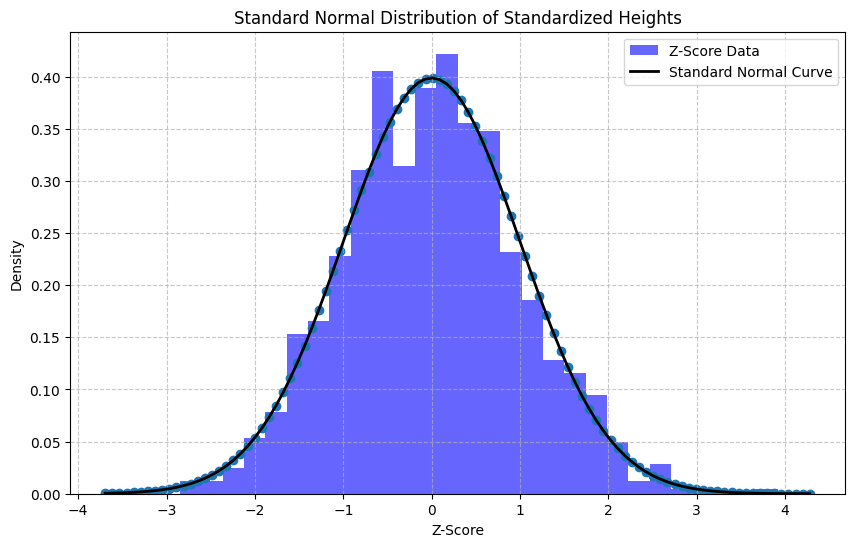

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set a random seed for reproducibility
np.random.seed(42)

# Define parameters for a normal distribution (e.g., student heights)
mean_height = 170  # in cm
std_dev_height = 10
num_students = 1000
# Generate a synthetic dataset for student heights
heights = np.random.normal(mean_height, std_dev_height, num_students)
# Standardize the heights to create a standard normal distribution
# Formula: z = (x - mean) / std_dev
z_scores = (heights - np.mean(heights)) / np.std(heights)

# Print a few z-scores to see the result
print("Sample of original heights (cm):", heights[:5])
print("Sample of standardized z-scores:", z_scores[:5])

# Verify the mean and standard deviation of the standardized data
print(f"Mean of z-scores: {np.mean(z_scores):.4f}")
# The standard deviation is a measure of how spread out the entire dataset is from the mean. 
print(f"Standard deviation of z-scores: {np.std(z_scores):.4f}")
# Let's plot the distribution of standard data(z-scores)
#ax1.hist(heights, bins=30, density=True, alpha=0.6, color='b', label='Height Data')
plt.figure(figsize=(10,6))
a = plt.hist(z_scores, bins=30, density=True, alpha=0.6, color='b', label='Z-Score Data')
xmin,xmax = plt.xlim()
print("xmin: ", xmin, "xmax: ", xmax)
x_standard = np.linspace(xmin, xmax, 100) # will give you the 100 z-scores between xmin and xmax which we use in calculate PDF
probability_of_z_scores = norm.pdf(x_standard, 0, 1)
plt.plot(x_standard, probability_of_z_scores, 'k', linewidth=2, label='Standard Normal Curve')
plt.title('Standard Normal Distribution of Standardized Heights')
plt.xlabel('Z-Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Question on standard deviation on above example- 
__how many standard deviations a student's height of 140 cm is from the mean? 
Solution - You need to calculate the z-score. The z-score represents the number of standard deviations a data point is from the mean of a dataset.
Mean = 170
standard deviation = 10
So by using formula : z = (x - mean) / std_dev
z-score will be 140-170/10 = -3
So, a student with a height of 140 cm is 3 standard deviations below the mean height of the class.__

__continuous uniform distribution__

__A continuous uniform distribution, also known as a rectangular distribution, is a probability distribution where every value within a given range has an equal chance of occurring. 🎲 Unlike the normal distribution, it doesn't have a peak or a bell curve; it's a flat, straight line. The probability density function (PDF) is constant between the minimum value, a, and the maximum value, b, and zero everywhere else. The total area under the PDF is always 1.__

__A real-life example/question is the waiting time for a bus that runs every 15 minutes. Assuming the bus is always on time and you arrive at the bus stop randomly, your waiting time could be anywhere between 0 and 15 minutes, and every waiting time in that interval is equally likely.__

Sample of generated waiting times (minutes): [ 3.85896597  9.68822505  0.78870605 14.17280354  0.24182818]
probaibility density of getting the bus from 0 to 15 minutes of mentioned waiting times:  [0. 0. 0. 0. 0.]


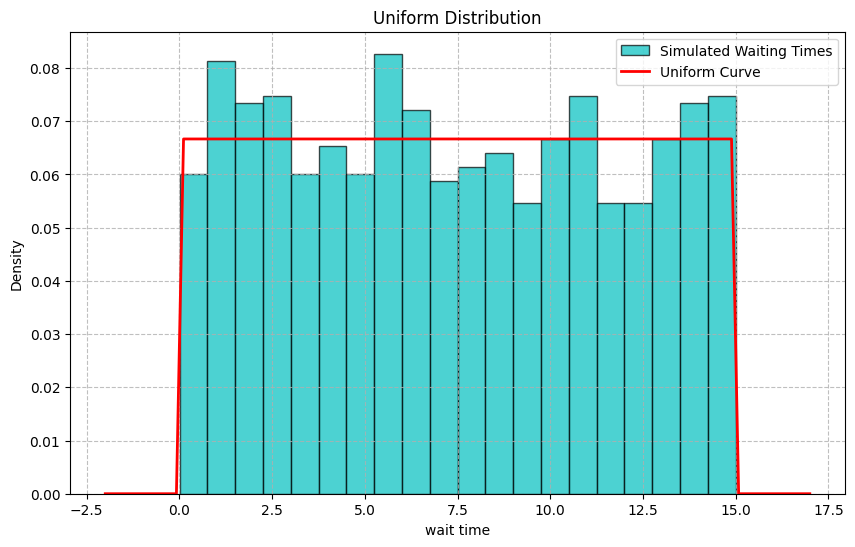

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Define the parameters for the uniform distribution
# a = minimum value, b = maximum value
min_time = 0   # in minutes
max_time = 15 # in minutes
# Generate a synthetic dataset of 1000 random waiting times
# The values will be uniformly distributed between min_time and max_time
num_observations = 1000
waiting_times = np.random.uniform(low=min_time, high=max_time, size=num_observations)
# Print a few sample waiting times
print("Sample of generated waiting times (minutes):", waiting_times[:5])
plt.figure(figsize=(10,6))
# Plot a histogram of the waiting times
# The 'density=True' argument normalizes the histogram so the total area is 1
plt.hist(waiting_times, bins=20, density=True, color='c', edgecolor='black', alpha=0.7, label='Simulated Waiting Times')
#xmin,xmax = plt.xlim() we don't need to calculate min and max in this, because min and max are the parameters given.
#print("xmin: ", xmin, "xmax: ", xmax)
x = np.linspace(min_time - 2, max_time + 2, 100) 
#print("x: ", x)
# loc=min_time: The loc parameter specifies the location of the distribution's starting point, which is the minimum value (min_time = 0).
# scale=max_time - min_time: The scale parameter specifies the width of the distribution. For a uniform distribution, 
# this is the range of possible values (15 - 0 = 15).
# This line calculates the height of the theoretical uniform distribution curve at each point in the x array. 
#The PDF value for a uniform distribution is constant across its range, equal to 1/(b−a). 
# B is max_time-min_time(15-0) as per below logic , a is min_time which is 0.
pdf = uniform.pdf(x, loc=min_time, scale=max_time - min_time)
print("probaibility density of getting the bus from 0 to 15 minutes of mentioned waiting times: ", pdf[:5])
plt.plot(x, pdf, 'r-', lw=2, label='Uniform Curve')
plt.title('Uniform Distribution')
plt.xlabel('wait time')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

Question - 
calculate the probability of the waiting time for the bus being between 4 and 10 minutes of above example.

In [9]:
# Define the parameters for the uniform distribution
# a = minimum value, b = maximum value
min_time = 0   # in minutes
max_time = 15 # in minutes
# Define the range for which we want to calculate the probability
start_range = 4
end_range = 10
# Calculate the width of the desired range
width = end_range - start_range
# Calculate the height of the uniform distribution's PDF
height = 1 / (max_time - min_time)
x = np.linspace(start_range, end_range, 1) 
# Get the Height: The uniform.pdf function gives you the constant height of the distribution for any point within its range. 
# We can use any number between 0 and 15, for example, 4. The function will return the constant probability density.
print("x ",x)
pdf = uniform.pdf(x, min_time, max_time)
print("probability density of height: ", pdf)
# Get the Width: This is simply the length of the interval, which is 10 - 4 = 6.
# Calculate the Area: Multiply the height you got from the PDF by the width.
print(f"probability to get the bus between {start_range} mins and {end_range} min is {pdf*(end_range-start_range)} ")
# Below way is easy and best way to calculate the probability using CDF.
#What is the probability the bus arrives between 0 and 4 minutes?
prob_at_4 = uniform.cdf(start_range, loc=min_time, scale=max_time - min_time)
#What is the probability the bus arrives between 0 and 10 minutes?
prob_at_10 = uniform.cdf(end_range, loc=min_time, scale=max_time - min_time)
print("prob_at_4 ", prob_at_4, "prob_at_10 ", prob_at_10)
print(f"probability to get the bus in waiting time between {start_range} mins and {end_range} min is {(prob_at_10-prob_at_4)} ")

#Key Takeaway: You can think of density as "probability per unit." or The Height of the graph at point \(x\).
# To get the actual probability, you must multiply that density by a range of values (the width). 



x  [4.]
probability density of height:  [0.06666667]
probability to get the bus between 4 mins and 10 min is [0.4] 
prob_at_4  0.26666666666666666 prob_at_10  0.6666666666666666
probability to get the bus in waiting time between 4 mins and 10 min is 0.39999999999999997 


question 2 in continuous uniform distribution:
and what if i only want to get the probability of get the bus in 6 mins only.
Answer : 
In a continuous uniform distribution, the probability of a single, exact value occurring is zero. 
This might seem counterintuitive, but think of it this way: there are an infinite number of possible waiting times between 0 and 15 minutes (e.g., 6 minutes, 6.01 minutes, 6.001 minutes, and so on). The probability is not at a single point but rather spread out over the entire interval.

Mathematically, probability in a continuous distribution is the area under the probability density function (PDF) curve. The area of a single point, which has a width of zero, is also zero.

Therefore, the probability of waiting for exactly 6 minutes is 0. This is true for any single, specific time you might choose, such as 4.5 minutes or 12.3 minutes.



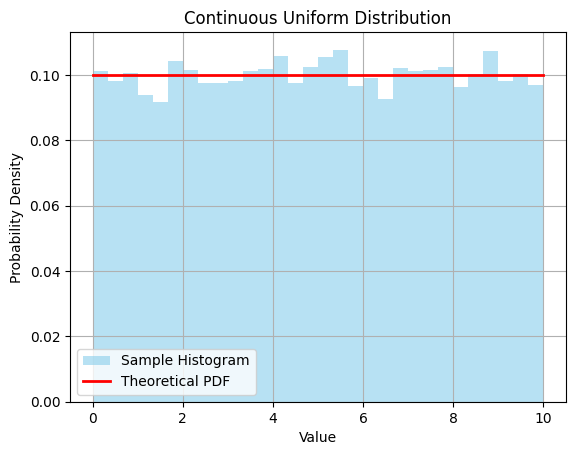

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters of the uniform distribution
a = 0  # Lower bound
b = 10 # Upper bound

# Generate random samples from the uniform distribution
num_samples = 10000
samples = np.random.uniform(a, b, num_samples)

# Create the histogram
plt.hist(samples, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample Histogram')

# Plot the theoretical PDF
x = np.linspace(a, b, 100) # Create x-values for plotting the PDF
pdf_values = np.ones_like(x) / (b - a) # Calculate the constant PDF value
plt.plot(x, pdf_values, 'r-', lw=2, label='Theoretical PDF')

# Add labels and title
plt.title('Continuous Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

__A Log-Normal distribution is a continuous probability distribution where the natural logarithm of a random variable is normally distributed. 📊__
This means if a variable, let's call it X, follows a Log-Normal distribution, and you take the natural logarithm of all its values, the resulting data will form a symmetrical, bell-shaped curve (a Normal distribution).

__Why It's Useful__
The Log-Normal distribution is different from the Normal distribution in a few key ways that make it useful for modeling certain real-world phenomena:

__Non-Negative__: A Log-Normal distribution is defined only for positive values. This makes it perfect for variables that can't be negative, such as income, asset prices, or body weight.


__Skewed__: It's always skewed to the right, with a long tail on the high end. This shape is common in nature and business, where most values are clustered at the low end but a few outliers are much larger (e.g., most people have a modest income, but a few have extremely high incomes).

__Multiplicative Growth__: It's often used to model processes where growth is proportional to the current value, such as compound interest or a biological organism's size increase.
__A log-normal distribution is defined by two primary parameters that describe the normal distribution of the natural logarithm of the data.__

__These two parameters are:__

__μ (mu):__ The mean of the variable's natural logarithm. This is a crucial distinction—it is not the mean of the final, skewed log-normal distribution itself. It tells you where the center of the underlying normal distribution is located on the log scale.

__σ (sigma):__ The standard deviation of the variable's natural logarithm. This is also not the standard deviation of the log-normal distribution. It describes the spread of the data on the log scale. A larger σ leads to a more positively skewed log-normal curve.

Diagram of normal distribution will always be bell - curve. most of the avg data will be close to the mean. But in case of log normal distribution. it will be right skewed. Why right skewed? we can understand with an real life example: most of the avg data will be on the left side and very few data will be on right side. like very few people earns billions of money(Jeff bezos, Ambani), and most of us are avg people who falls on the left side of the chart. 
But if we apply log function to the data set(x axis of right skewed data), it will become normal distribution(bell curve).

__The "log-normal" part of the name comes from a crucial insight: while the income data itself is skewed, the natural logarithm of the income data is a symmetrical, normally distributed bell curve.__

__By transforming the data with a natural logarithm into normal distribution, you can use all the powerful statistical tools and formulas of the normal distribution to analyze the income data. For instance, you could calculate the probability of a randomly selected person earning within a certain income bracket or determine a confidence interval for the average income of the population.__

The Core Reason: To Use Normal Distribution's Powerful Statistical Toolkit
The normal distribution is the most studied and best-understood distribution in all of statistics. Almost every statistical test, model, and concept—from t-tests and Z-scores to confidence intervals and hypothesis testing—is based on the assumption that the data is normally distributed.
When your data is skewed (like income), you can't use these methods directly, or they will produce inaccurate and misleading results. By converting the log-normal data to a normal distribution, you can now apply all of those powerful tools.

Here is the Python code for a log-normal distribution using a common real-life example: household income. 💰

--- Descriptive Statistics of the DataFrame ---
       Household Income ($)
count          1.000000e+04
mean           1.033747e+05
std            9.414210e+04
min            2.413735e+03
25%            4.420921e+04
50%            7.621247e+04
75%            1.299855e+05
max            1.269925e+06




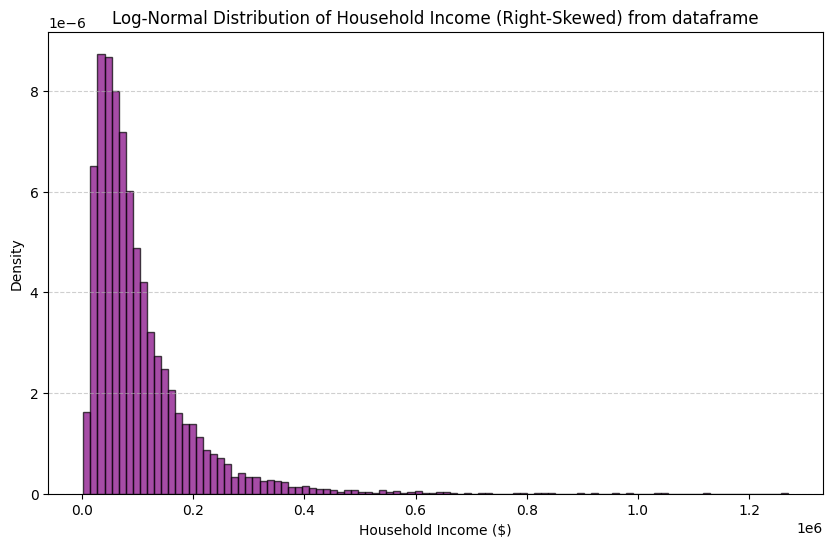

--- Key Percentiles ---
25th Percentile: $44209.21
50th Percentile (Median): $76212.47
75th Percentile: $129985.48
Generated data statistics for 10000 households:
--------------------------------------------------
Mean Income: $103374.74
Median Income: $76212.47
Standard Deviation: $94137.39


In [44]:
#This code generates a synthetic dataset of 10,000 household incomes and visualizes the log-normal distribution.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

# Define the parameters for the underlying normal distribution of the log of income
# These parameters are based on real-world income distributions.
# The `scale` parameter of lognorm.rvs is the median of the distribution.
mu_log = np.log(75000)  # Mean of the log-transformed data, corresponding to a median income of $75,000
sigma_log = 0.8        # Standard deviation of the log-transformed data

# --- 1. Generate Log-Normal Data ---
# We use lognorm.rvs to generate 10,000 random samples of income.
# s is the shape parameter (sigma_log).
# scale is the median of the distribution (exp(mu_log)).
num_households = 10000
household_incomes = lognorm.rvs(s=sigma_log, scale=np.exp(mu_log), size=num_households)
# --- 2. Create a Pandas DataFrame ---
# We store the generated data in a DataFrame for easier analysis and manipulation.
income_df = pd.DataFrame(household_incomes, columns=['Household Income ($)'])
# --- 3. Display Descriptive Statistics ---
# The describe() method gives us a quick summary of the data.
print("--- Descriptive Statistics of the DataFrame ---")
print(income_df.describe())
print("\n" + "="*50 + "\n")
# --- 2. Plot the Distribution ---
plt.figure(figsize=(10, 6))
income_df['Household Income ($)'].plot(kind='hist', bins=100, density=True, color='purple', edgecolor='black', alpha=0.7)
plt.title('Log-Normal Distribution of Household Income (Right-Skewed) from dataframe')
plt.xlabel('Household Income ($)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- 3. Display Key Statistics ---
# Note how the mean is greater than the median due to the skew.
mean_income = np.mean(household_incomes)
median_income = np.median(household_incomes)
std_dev_income = np.std(household_incomes)
# --- 5. Display key percentiles to show skewness ---
print("--- Key Percentiles ---")
print(f"25th Percentile: ${income_df['Household Income ($)'].quantile(0.25):.2f}")
print(f"50th Percentile (Median): ${income_df['Household Income ($)'].median():.2f}")
print(f"75th Percentile: ${income_df['Household Income ($)'].quantile(0.75):.2f}")

print(f"Generated data statistics for {num_households} households:")
print("-" * 50)
print(f"Mean Income: ${mean_income:.2f}")
print(f"Median Income: ${median_income:.2f}")
print(f"Standard Deviation: ${std_dev_income:.2f}")
#Now we have got the mean, median and standard deviation after converting from log normal distribution to normal distribution.
# we can calculate the probability.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 166.9 kB/s eta 0:00:00 kB/s eta 0:00:01:01
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 255.6 kB/s eta 0:00:00m eta 0:00:010:00:02
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
Note: you may need to restart the kernel to use updated packages.
